# Safe Infrastructure or Risk Signal? Predicting Serious Collision Severity around Pedestrian Crossing Facilities in London

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......
AI声明

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

In London, a policy priority called Vision Zero aims to eliminate deaths and serious injuries from the transport network, and safer streets are needed to support walking and cycling (www.london.gov.uk. (n.d.)). Understanding why collisions become severe is therefore important for road safety and planning. 

Existing research has used machine learning to predict pedestrian crash severity at signalised intersections. It shows that spatial and traffic-related factors can support severity prediction (Kuşkapan et al., 2022). Built environment studies have used XGBoost and SHAP to explain fatal pedestrian accident risk at specific locations (Chang et al., 2022). Recent intersection research extends the 5D built-environment framework by adding detailed intersection-interface features (Chen et al., 2026). Crossing safety studies also show that facilities are not always simple safety indicators: collision risk can be higher at some signalised or marked crossings, and unsignalised zebra crossings can still involve fatality risk (Quistberg et al., 2015; Olszewski et al., 2015).

This highlights the gap between traditional intuition and empirical evidence.Crossing facilities are often treated as protective infrastructure, but they may also mark high conflict locations with more pedestrians, turning vehicles and complex junction layouts. Their role has not been tested enough within an interpretable machine-learning prediction framework.

This study examines whether pedestrian crossing facilities are associated with lower serious collision severity in London, or whether they act as signals of high-risk junction contexts in machine learning predictions.

## Research questions

[[ go back to the top ]](#Table-of-contents)

This study addresses two research questions.

RQ1: How do severe collision rates vary across pedestrian crossing facility types and junction contexts in London in 2024?

RQ2: Can machine learning models identify serious or fatal collisions in London, and which road-context variables contribute most to severity prediction?

## Data

[[ go back to the top ]](#Table-of-contents)

In [36]:
# 3.1 Install and import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import requests

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score,
    recall_score, f1_score, accuracy_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve
)

warnings.filterwarnings('ignore')
print("All packages imported successfully")

All packages imported successfully


**Data sources and preparation**

This study draws on two STATS19 datasets published by the Department for Transport (2024): the collision dataset and the casualty dataset. The full GB collision dataset contains 100,927 records and the casualty dataset contains 128,272 records. Records were filtered to Greater London using ONS local authority district codes beginning with E09, retaining 20,967 London collisions across 33 boroughs. The collision_index field was used solely to merge the two datasets and was excluded from all model features.

In [37]:
# 3.2 Load collision and casualty datasets from GitHub

COLLISION_URL = (
    'https://raw.githubusercontent.com/Alexia418/'
    'DSSS_Assessment/main/'
    'dft-road-casualty-statistics-collision-2024.csv'
)
CASUALTY_URL = (
    'https://raw.githubusercontent.com/Alexia418/'
    'DSSS_Assessment/main/'
    'dft-road-casualty-statistics-casualty-2024.csv'
)

collision = pd.read_csv(COLLISION_URL, low_memory=False)
casualty  = pd.read_csv(CASUALTY_URL,  low_memory=False)

print(f"Collision records (GB): {len(collision):,}")
print(f"Casualty records  (GB): {len(casualty):,}")

Collision records (GB): 100,927
Casualty records  (GB): 128,272


In [38]:
# 3.3 Filter to London using ONS district codes (E09 = London boroughs)

london_col = collision[
    collision['local_authority_ons_district']
    .astype(str).str.startswith('E09')
].copy()

london_cas = casualty[
    casualty['collision_index'].isin(london_col['collision_index'])
].copy()

print(f"London collisions: {len(london_col):,}")
print(f"London casualties: {len(london_cas):,}")
print(f"Unique boroughs:   {london_col['local_authority_ons_district'].nunique()}")

London collisions: 20,967
London casualties: 23,997
Unique boroughs:   33


In [39]:
# 3.4 Aggregate pedestrian casualties to collision level and join
# casualty_class = 3: Pedestrian; cross-validated against casualty_type = 0

ped = london_cas[london_cas['casualty_class'] == 3].copy()

ped_agg = ped.groupby('collision_index').agg(
    ped_casualty_count=('casualty_severity', 'count'),
    ped_severe_count=('casualty_severity', lambda x: (x.isin([1,2])).sum()),
    has_ped_casualty=('casualty_severity', lambda x: 1)
).reset_index()

london = london_col.merge(ped_agg, on='collision_index', how='left')
london['has_ped_casualty'] = london['has_ped_casualty'].fillna(0).astype(int)

print(f"Pedestrian casualties: {len(ped):,}")
print(f"Merged dataset rows:   {len(london):,}")

Pedestrian casualties: 4,445
Merged dataset rows:   20,967


The binary target variable was derived from the STATS19 collision_severity field: severe (1) for fatal or serious collisions (codes 1 and 2), and slight (0) for non-serious collisions (code 3).

In [40]:
# 3.5 Create binary target variable
# collision_severity: 1=Fatal, 2=Serious, 3=Slight (STATS19)

london['severe'] = london['collision_severity'].apply(
    lambda x: 1 if x in [1, 2] else 0
)

print(f"Severe cases: {london['severe'].sum():,} ({london['severe'].mean():.1%})")
print(f"Slight cases: {(london['severe']==0).sum():,}")

Severe cases: 3,601 (17.2%)
Slight cases: 17,366



**Feature engineering and cleaning**

Two temporal features were derived: hour of day (extracted from the raw time field) and binary indicators for peak hour (07:00–09:00 and 16:00–19:00) and weekend. A borough-level severe collision rate was computed as a spatial context variable. Prior to modelling, rows containing ambiguous or unknown codes were removed using variable-specific rules. The largest exclusions were junction_control (5,880 rows, 28.0%) and junction_detail (2,256 rows, 10.8%). After sequential cleaning, 9,205 rows were removed in total, leaving a final analytical dataset of 11,762 collisions. Of these, 2,266 (19.3%) are classified as severe, yielding a class imbalance ratio of approximately 4.2:1. No missing values remained after cleaning. All categorical variables were one-hot encoded using pd.get_dummies, producing 53 features in total. Numeric features (speed_limit and hour) were retained in their original continuous form.

In [41]:
# 3.6 Engineer temporal and spatial features

london['hour']        = london['time'].str[:2].astype(float)
london['peak_hour']   = london['hour'].apply(lambda x: 1 if (7<=x<=9) or (16<=x<=19) else 0)
london['weekend']     = london['day_of_week'].apply(lambda x: 1 if x in [1,7] else 0)
london['has_crossing'] = london['pedestrian_crossing_physical_facilities_historic'].apply(
    lambda x: 0 if x in [0, 9] else 1
)

print("Features created: hour, peak_hour, weekend, has_crossing")

Features created: hour, peak_hour, weekend, has_crossing


In [42]:
# 3.7 Compute borough-level severe collision rate as spatial context variable

borough_rate = (
    london.groupby('local_authority_ons_district')['severe']
    .mean()
    .rename('borough_severe_rate')
)
london = london.drop(columns=['borough_severe_rate'], errors='ignore').join(
    borough_rate, on='local_authority_ons_district'
)

print(f"Boroughs: {borough_rate.shape[0]}")
print(borough_rate.sort_values(ascending=False).head())

Boroughs: 33
local_authority_ons_district
E09000001    0.325301
E09000027    0.268437
E09000028    0.245714
E09000020    0.221631
E09000021    0.214533
Name: borough_severe_rate, dtype: float64


In [43]:
# 3.8 Inspect ambiguous and missing codes before exclusion

pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)

AMBIGUOUS_CODES = {
    'pedestrian_crossing_physical_facilities_historic': [-1, 99],
    'junction_detail':         [-1, 99],
    'junction_control':        [-1, 9],
    'road_type':               [-1, 9],
    'speed_limit':             [-1, 99],
    'light_conditions':        [-1],
    'weather_conditions':      [-1, 9],
    'road_surface_conditions': [-1, 9],
    'urban_or_rural_area':     [-1],
    'day_of_week':             [-1],
}

rows = []
for col, codes in AMBIGUOUS_CODES.items():
    if col not in london.columns:
        continue
    total      = len(london)
    ambig      = london[col].isin(codes).sum()
    nan        = london[col].isnull().sum()
    total_miss = ambig + nan
    rows.append({'variable': col, 'ambiguous': ambig,
                 'NaN': nan, 'total_missing': total_miss,
                 'pct': round(total_miss/total*100, 1)})

print(pd.DataFrame(rows).sort_values('pct', ascending=False).to_string(index=False))

                                        variable  ambiguous  NaN  total_missing  pct
                                junction_control       5880    0           5880 28.0
                                 junction_detail       2256    0           2256 10.8
                                       road_type       2216    0           2216 10.6
                              weather_conditions       1905    0           1905  9.1
                         road_surface_conditions       1625    0           1625  7.8
pedestrian_crossing_physical_facilities_historic        181    0            181  0.9
                                     speed_limit          0    0              0  0.0
                                light_conditions          0    0              0  0.0
                             urban_or_rural_area          0    0              0  0.0
                                     day_of_week          0    0              0  0.0


In [44]:
# 3.9 Define model features and target

FEATURES = [
    'pedestrian_crossing_physical_facilities_historic',
    'junction_detail',
    'junction_control',
    'road_type',
    'speed_limit',
    'urban_or_rural_area',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'day_of_week',
    'hour',
    'peak_hour',
    'weekend',
]

TARGET = 'severe'

In [45]:
# 3.10 Remove rows with invalid codes using variable-specific rules
# Code 9 in crossing variable = unknown (self-reported) - excluded
# Code 9 in junction_control, road_type, weather, road_surface = unknown — excluded

INVALID_CODES = {
    'pedestrian_crossing_physical_facilities_historic': [-1, 9],  # 9 = unknown (self reported)
    'junction_detail':         [-1, 99],
    'junction_control':        [-1, 9],
    'road_type':               [-1, 9],
    'speed_limit':             [-1, 99],
    'light_conditions':        [-1],
    'weather_conditions':      [-1, 9],
    'road_surface_conditions': [-1, 9],
    'urban_or_rural_area':     [-1],
    'day_of_week':             [-1],
}

df_model = london[FEATURES + [TARGET]].copy()

for col, codes in INVALID_CODES.items():
    before = len(df_model)
    df_model = df_model[~df_model[col].isin(codes)]
    removed = before - len(df_model)
    if removed > 0:
        print(f"Removed {removed:>5} rows — {col}")

df_model = df_model.dropna()
print(f"\nFinal: {len(df_model):,} rows")
print(f"Severe: {df_model[TARGET].sum():,} ({df_model[TARGET].mean():.1%})")

Removed  3690 rows — pedestrian_crossing_physical_facilities_historic
Removed   996 rows — junction_detail
Removed  3718 rows — junction_control
Removed   338 rows — road_type
Removed   396 rows — weather_conditions
Removed    67 rows — road_surface_conditions

Final: 11,762 rows
Severe: 2,266 (19.3%)


In [46]:
# 3.11 Verify no remaining missing values

missing = df_model[FEATURES].isnull().sum()
print("Missing values:", "None" if missing.sum()==0 else missing[missing>0])
print(f"Shape: {df_model.shape}")

Missing values: None
Shape: (11762, 14)


**Variable Table**

| Variable | Source | Type | Description | Notes |
|---|---|---|---|---|
| severe | Collision | Binary | Target: 1 = Fatal or Serious, 0 = Slight | Derived from collision_severity codes 1 and 2 |
| pedestrian_crossing_physical_facilities_historic | Collision | Categorical | Pedestrian crossing facility type within 50m | Core variable of interest; codes 0,1,4,5,7,8 retained |
| junction_detail | Collision | Categorical | Junction type at collision location | |
| junction_control | Collision | Categorical | Traffic control type at junction | |
| road_type | Collision | Categorical | Road classification | |
| speed_limit | Collision | Numeric | Posted speed limit in mph | |
| urban_or_rural_area | Collision | Categorical | Urban or rural classification | |
| light_conditions | Collision | Categorical | Lighting at time of collision | |
| weather_conditions | Collision | Categorical | Weather at time of collision | |
| road_surface_conditions | Collision | Categorical | Road surface condition | |
| day_of_week | Collision | Categorical | Day of week | 1 = Sunday, 7 = Saturday |
| hour | Collision | Numeric | Hour of day (0–23) | Extracted from time field |
| peak_hour | Collision | Binary | Peak hour indicator | 1 = 07:00–09:59 or 16:00–19:59 |
| weekend | Collision | Binary | Weekend indicator | 1 = Saturday or Sunday |

In [47]:
# 3.12 Define categorical and numeric feature groups

CAT_FEATURES = [
    'pedestrian_crossing_physical_facilities_historic',
    'junction_detail',
    'junction_control',
    'road_type',
    'urban_or_rural_area',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'day_of_week',
    'peak_hour',
    'weekend',
]

NUM_FEATURES = [
    'speed_limit',
    'hour',
]

**Exploratory Data Analysis**

EDA examined the distribution of the target variable, severe collision rates across crossing facility types and junction contexts, and the spatial distribution of collisions across London boroughs. Class imbalance and the interaction between crossing facility type and junction type were assessed to inform modelling choices and to address RQ1.

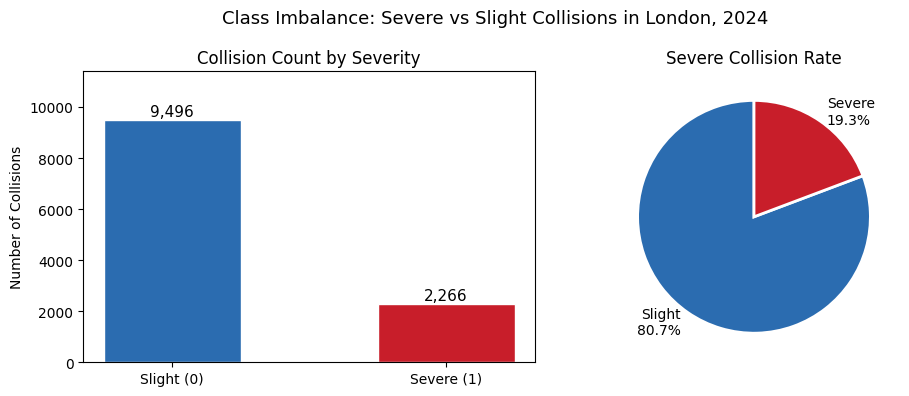

Severe rate: 0.193
Imbalance ratio: 4.2:1


In [48]:
# 3.13 EDA 1: Severity class distribution

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

severity_counts = df_model['severe'].value_counts().sort_index()
severity_labels = ['Slight (0)', 'Severe (1)']
colors = ['#2B6CB0', '#C81E2A']

axes[0].bar(severity_labels, severity_counts.values,
            color=colors, edgecolor='white', width=0.5)
for bar, count in zip(axes[0].patches, severity_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Collision Count by Severity')
axes[0].set_ylabel('Number of Collisions')
axes[0].set_ylim(0, severity_counts.max() * 1.2)

rates = [1 - df_model['severe'].mean(), df_model['severe'].mean()]
axes[1].pie(rates,
            labels=[f'Slight\n{rates[0]*100:.1f}%', f'Severe\n{rates[1]*100:.1f}%'],
            colors=colors,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Severe Collision Rate')

plt.suptitle('Class Imbalance: Severe vs Slight Collisions in London, 2024', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Severe rate: {df_model['severe'].mean():.3f}")
print(f"Imbalance ratio: {(df_model['severe']==0).sum()/df_model['severe'].sum():.1f}:1")

**Class Imbalance**

The final dataset contains 11,762 collisions, of which 2,266 (19.3%) are classified as severe, yielding a slight-to-severe imbalance ratio of 4.2:1.

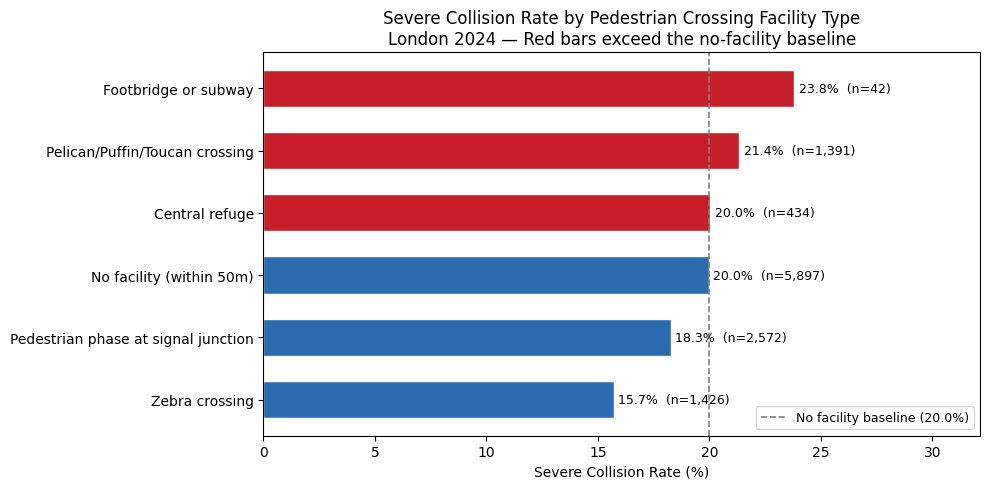

In [49]:
# 3.14 EDA 2: Severe rate by crossing facility type

facility_labels = {
    0: 'No facility (within 50m)',
    1: 'Zebra crossing',
    4: 'Pelican/Puffin/Toucan crossing',
    5: 'Pedestrian phase at signal junction',
    7: 'Footbridge or subway',
    8: 'Central refuge',
    9: 'Unknown (self-reported)'
}

crossing_rate = (
    df_model.groupby('pedestrian_crossing_physical_facilities_historic')['severe']
    .agg(severe_rate='mean', count='count')
    .reset_index()
)
crossing_rate['label'] = (
    crossing_rate['pedestrian_crossing_physical_facilities_historic']
    .map(facility_labels).fillna('Other')
)
crossing_rate = crossing_rate.sort_values('severe_rate', ascending=True)

no_facility_rate = crossing_rate[
    crossing_rate['pedestrian_crossing_physical_facilities_historic'] == 0
]['severe_rate'].values[0]

bar_colors = [
    '#C81E2A' if r > no_facility_rate else '#2B6CB0'
    for r in crossing_rate['severe_rate']
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(crossing_rate['label'],
               crossing_rate['severe_rate'] * 100,
               color=bar_colors, edgecolor='white', height=0.6)

for bar, rate, n in zip(bars, crossing_rate['severe_rate'], crossing_rate['count']):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f'{rate*100:.1f}%  (n={n:,})', va='center', fontsize=9)

ax.axvline(no_facility_rate * 100, color='grey', linestyle='--', linewidth=1.2,
           label=f'No facility baseline ({no_facility_rate*100:.1f}%)')
ax.set_xlabel('Severe Collision Rate (%)')
ax.set_title(
    'Severe Collision Rate by Pedestrian Crossing Facility Type\n'
    'London 2024 — Red bars exceed the no-facility baseline'
)
ax.legend(fontsize=9)
ax.set_xlim(0, crossing_rate['severe_rate'].max() * 100 * 1.35)
plt.tight_layout()
plt.show()

**Severe rates by crossing facility type**

Severe collision rates vary across crossing facility types. Footbridge or subway recorded the highest rate at 23.8%, while Zebra crossings recorded the lowest at 15.7%. The no-facility baseline stands at 20%. These patterns indicate that crossing facility type does not map straightforwardly onto a protective direction.

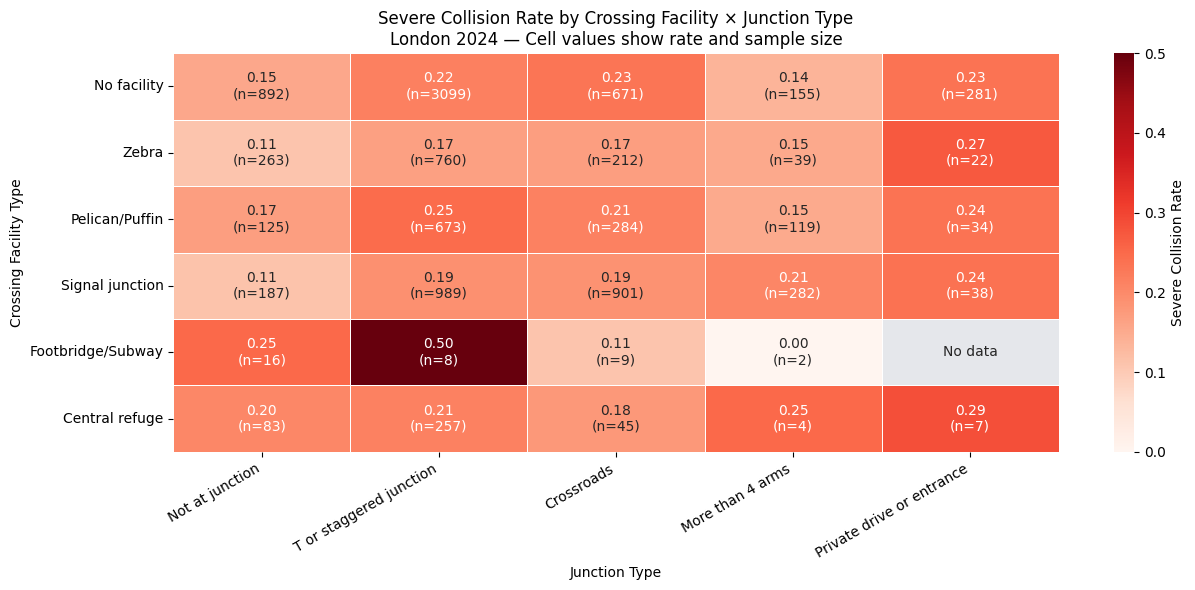

Severe rate range: 0.00 to 0.50


In [50]:
# 3.15 EDA 3: Severe rate by crossing facility × junction type

junction_labels = {
    0:  'Not at junction',
    13: 'T or staggered junction',
    16: 'Crossroads',
    17: 'More than 4 arms',
    18: 'Private drive or entrance',
}

crossing_labels_short = {
    0: 'No facility',
    1: 'Zebra',
    4: 'Pelican/Puffin',
    5: 'Signal junction',
    7: 'Footbridge/Subway',
    8: 'Central refuge',
}

valid_junctions = [0, 13, 16, 17, 18]
plot_df = df_model[df_model['junction_detail'].isin(valid_junctions)].copy()

pivot = (
    plot_df.groupby([
        'pedestrian_crossing_physical_facilities_historic',
        'junction_detail'
    ])['severe'].mean().unstack()
)

count_pivot = (
    plot_df.groupby([
        'pedestrian_crossing_physical_facilities_historic',
        'junction_detail'
    ])['severe'].count().unstack()
)

pivot.index = [crossing_labels_short.get(i, str(i)) for i in pivot.index]
pivot.columns = [junction_labels.get(c, str(c)) for c in pivot.columns]
count_pivot.index = [crossing_labels_short.get(i, str(i)) for i in count_pivot.index]
count_pivot.columns = [junction_labels.get(c, str(c)) for c in count_pivot.columns]

# Annotation: show rate and count together
annot = pivot.copy().astype(object)

for row in pivot.index:
    for col in pivot.columns:
        rate = pivot.loc[row, col]
        n = count_pivot.loc[row, col]

        if pd.notna(rate):
            annot.loc[row, col] = f'{rate:.2f}\n(n={int(n)})'
        else:
            annot.loc[row, col] = 'No data'

# Important:
# seaborn hides NaN cells completely, so create a plotting-only version.
# plot_values is used only for rendering; all analysis uses pivot (which preserves NaN)
plot_values = pivot.fillna(-0.01)

# Make values below vmin appear grey
cmap = plt.cm.Reds.copy()
cmap.set_under('#e5e7eb')  # light grey for no data

fig, ax = plt.subplots(figsize=(13, 6))

sns.heatmap(
    plot_values,
    annot=annot,
    fmt='',
    cmap=cmap,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    vmin=0,
    vmax=0.5,
    cbar_kws={'label': 'Severe Collision Rate'}
)

ax.set_title(
    'Severe Collision Rate by Crossing Facility × Junction Type\n'
    'London 2024 — Cell values show rate and sample size',
    fontsize=12
)

ax.set_xlabel('Junction Type')
ax.set_ylabel('Crossing Facility Type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(f"Severe rate range: {pivot.min().min():.2f} to {pivot.max().max():.2f}")

**Crossing facility × junction type interaction**

The heatmap of severe rates across crossing facility and junction type combinations reveals a range from 0.00 to 0.50. This wide variation confirms that junction context is a critical moderating factor: the same facility type can be associated with markedly different severe rates depending on the junction type. Cells with small sample sizes should be interpreted with caution.

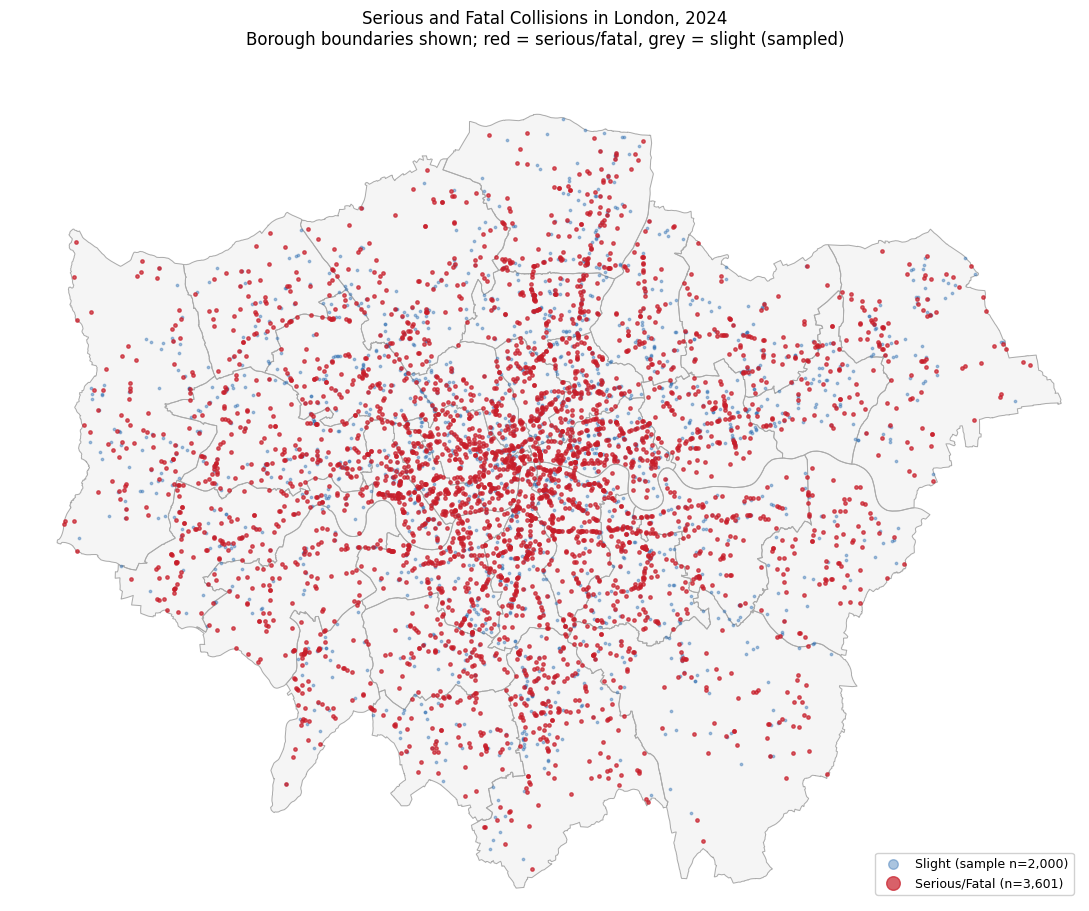

Serious/Fatal plotted: 3,601
Slight sampled:        2,000


In [51]:
# 3.16 EDA 4: Spatial distribution of severe collisions in London
# Borough boundary outlines only (no fill), collision points coloured by severity
# Aspect ratio corrected for London latitude; axes removed for clean map style

import requests
import numpy as np

fig, ax = plt.subplots(figsize=(11, 10))

# Fetch borough boundary outlines
geojson_url = (
    'https://raw.githubusercontent.com/radoi90/housequest-data/'
    'master/london_boroughs.geojson'
)
response = requests.get(geojson_url, timeout=10)
borough_geojson = response.json()

# Draw borough outlines only — no fill
for feature in borough_geojson['features']:
    geom_type = feature['geometry']['type']
    coords_list = feature['geometry']['coordinates']
    if geom_type == 'Polygon':
        coords_list = [coords_list]
    for polygon_coords in coords_list:
        outer = polygon_coords[0]
        xs = [pt[0] for pt in outer]
        ys = [pt[1] for pt in outer]
        ax.fill(xs, ys, color='#f5f5f5', zorder=0)
        ax.plot(xs, ys, color='#aaaaaa', linewidth=0.7, zorder=1)

# Sample slight collisions to reduce overplotting
slight = london[london['severe'] == 0].sample(
    n=min(2000, (london['severe'] == 0).sum()),
    random_state=42
)
severe_pts = london[london['severe'] == 1]

ax.scatter(
    slight['longitude'], slight['latitude'],
    s=3, alpha=0.4, c='#2B6CB0',
    label=f'Slight (sample n={len(slight):,})',
    zorder=2
)

ax.scatter(
    severe_pts['longitude'], severe_pts['latitude'],
    s=6, alpha=0.7, c='#C81E2A',
    label=f'Serious/Fatal (n={len(severe_pts):,})',
    zorder=3
)

# Correct aspect ratio for London latitude (~51.5 degrees)
# 1 degree longitude = cos(51.5°) × 1 degree latitude in physical distance
ax.set_aspect(1 / np.cos(np.radians(51.5)))

ax.set_xlim(-0.55, 0.35)
ax.set_ylim(51.28, 51.72)
ax.axis('off')

ax.set_title(
    'Serious and Fatal Collisions in London, 2024\n'
    'Borough boundaries shown; red = serious/fatal, grey = slight (sampled)',
    fontsize=12, pad=12
)
ax.legend(
    markerscale=4, fontsize=9,
    loc='lower right', framealpha=0.9
)

plt.tight_layout()
plt.show()

print(f"Serious/Fatal plotted: {len(severe_pts):,}")
print(f"Slight sampled:        {len(slight):,}")

**Spatial Pattern**

The spatial map shows that serious and fatal collisions (n=3,601 before cleaning) are distributed across all London boroughs without strong geographic concentration, suggesting that severity is more strongly associated with local road environment characteristics than with borough-level spatial patterns.

In [52]:
# 3.17 One-hot encode and three-way train/validation/test split
# Train: 60%, Validation: 20%, Test: 20%
# Validation set used for threshold optimisation only
# Test set held out for final evaluation — never used during training or tuning

df_encoded = df_model.copy()
df_encoded[CAT_FEATURES] = df_encoded[CAT_FEATURES].astype(str)
df_encoded = pd.get_dummies(df_encoded, columns=CAT_FEATURES)

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

# Step 1: split off 20% test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Step 2: split remaining 80% into 60% train and 20% validation
# test_size=0.25 of 80% = 20% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,
    random_state=42,
    stratify=y_trainval
)

print(f"Total dataset:  {len(X):,}")
print(f"Train:          {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation:     {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test:           {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Check total:    {X_train.shape[0]+X_val.shape[0]+X_test.shape[0]:,}")
print(f"Features:       {X.shape[1]}")
print(f"\nSevere rate:")
print(f"  Train:      {y_train.mean():.3f}")
print(f"  Validation: {y_val.mean():.3f}")
print(f"  Test:       {y_test.mean():.3f}")

Total dataset:  11,762
Train:          7,056 (60%)
Validation:     2,353 (20%)
Test:           2,353 (20%)
Check total:    11,762
Features:       53

Severe rate:
  Train:      0.193
  Validation: 0.193
  Test:       0.193


**Data Splitting**

The dataset of 11,762 collisions was divided into three stratified sets: 7,056 (60%) for training, 2,353 (20%) for validation, and 2,353 (20%) for testing. Stratified splitting preserved the severe rate of 19.3% across all three sets. The validation set was used exclusively for threshold optimisation. The test set was held out and applied only once for final evaluation.

## Methodology

[[ go back to the top ]](#Table-of-contents)

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

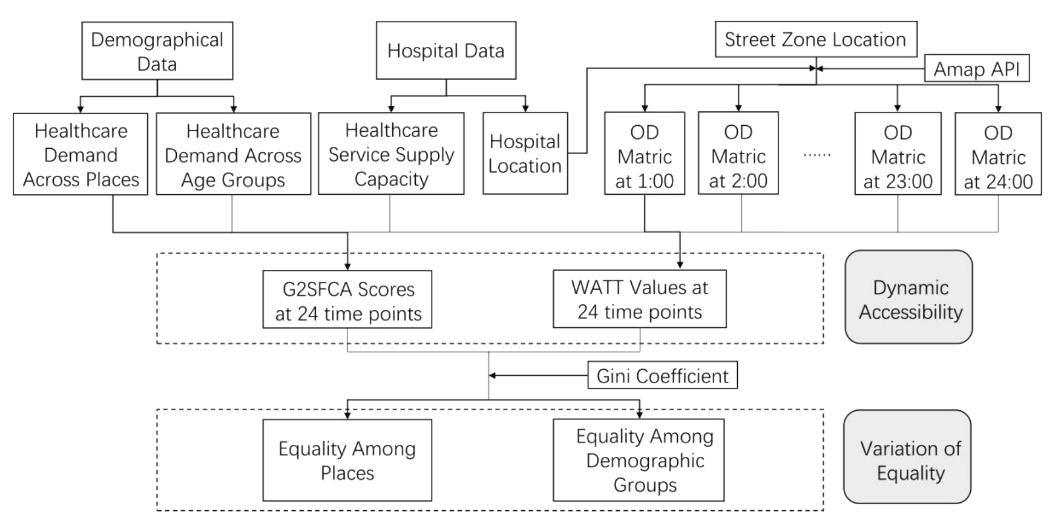

The analysis is conducted at collision level rather than area-level aggregation, as the research question concerns the probability of a severe outcome conditional on a collision occurring, not the frequency of collisions across spatial units. All recorded personal injury collisions in London in 2024 are included. Pedestrian crossing facility type is treated as a road environment variable characterising the infrastructure context at each collision location.

**Multicollinearity Assessment**

Prior to modelling, the Variance Inflation Factor (VIF) was computed for all numeric features to detect multicollinearity that could distort Logistic Regression coefficients. VIF for feature $x_i$ is defined as:

$$VIF_i = \frac{1}{1 - R_i^2}$$

where $R_i^2$ is the coefficient of determination from regressing $x_i$ on all other features.


**Classification Models**

The prediction task is framed as binary classification, estimating the probability of a severe outcome given a collision has occurred. Three models are employed, each wrapped in a scikit-learn Pipeline to ensure consistent preprocessing and avoid data leakage between training and evaluation.

**Logistic Regression** serves as a linear baseline. It models the log-odds of a severe collision as a linear combination of features passed through the sigmoid function:
$$P(Y=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \cdots + \beta_n X_n)}}$$
Class imbalance is addressed via class_weight='balanced'. Features are standardised using StandardScaler within the pipeline.

**Random Forest** constructs an ensemble of T decision trees, each trained on a bootstrap sample, with the final prediction determined by majority vote:
$$\hat{y} = \text{mode}\{h_1(X), h_2(X), \ldots, h_T(X)\}$$
Hyperparameters were tuned using GridSearchCV with 5-fold StratifiedKFold cross-validation, optimising average precision (PR-AUC) on the training set only. The selected parameters are reported in the Results section.

**Gradient Boosting** builds trees sequentially, where each new tree $h_m$ corrects the residuals of the current ensemble:
$$F_m(X) = F_{m-1}(X) + \eta \cdot h_m(X)$$
where $\eta$ is the learning rate. Hyperparameters were tuned using the same GridSearchCV procedure as Random Forest. The selected parameters are reported in the Results section.

**Evaluation and Interpretation**

Model performance is evaluated using six metrics across all three models. Accuracy is reported but is not the primary criterion given class imbalance. Recall is prioritised because a false negative (a severe collision classified as slight) is more consequential for road safety targeting than a false positive. 

**Recall** measures the proportion of true severe collisions correctly identified:
$$\text{Recall} = \frac{TP}{TP + FN}$$

**Precision** measures the proportion of predicted severe collisions that are truly severe:
$$\text{Precision} = \frac{TP}{TP + FP}$$

**F1-score** balances precision and recall:
$$F_1 = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$


**MCC** (Matthews Correlation Coefficient) provides a balanced single-value summary under class imbalance by accounting for all four cells of the confusion matrix:
$$
MCC = \frac{TP \times TN - FP \times FN}
{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}
$$


**PR-AUC** (Area under the Precision-Recall curve) summarises performance across all thresholds and is more informative than ROC-AUC under class imbalance, where the random baseline equals the severe class prevalence of 19.3%.


**SHAP** (SHapley Additive exPlanations) was applied to the Gradient Boosting model to decompose each prediction into additive feature contributions. For a feature $x_i$, its SHAP value is:
$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f(S \cup \{i\}) - f(S) \right]$$
A positive SHAP value indicates the feature increases the predicted probability of a severe outcome.




## Results and discussion

[[ go back to the top ]](#Table-of-contents)

In [53]:
# 5.1 VIF check for numeric features

vif_data = df_model[NUM_FEATURES].copy()

vif_results = pd.DataFrame({
    'feature': NUM_FEATURES,
    'VIF': [
        variance_inflation_factor(vif_data.values, i)
        for i in range(len(NUM_FEATURES))
    ]
}).sort_values('VIF', ascending=False)

print("Variance Inflation Factor:")
print(vif_results.to_string(index=False))
print("\nVIF < 5: low | VIF 5-10: moderate | VIF > 10: problematic")

Variance Inflation Factor:
    feature      VIF
       hour 4.942201
speed_limit 4.942201

VIF < 5: low | VIF 5-10: moderate | VIF > 10: problematic


Both numeric features returned VIF values below 5 (speed_limit: 4.94, hour: 4.94), confirming no problematic multicollinearity.

**Threshold Optimisation**

The default threshold of 0.5 is inappropriate under class imbalance: a naive classifier predicting all collisions as slight would achieve 80.7% (=100% - 19.3%) accuracy, making accuracy a misleading target. For each model, the threshold was selected on the validation set to minimise deviation from a target accuracy of 0.60–0.65, subject to a minimum recall of 0.20. Pure F1 maximisation was rejected as it would produce very low thresholds for tree-based models, resulting in high recall but operationally unrealistic precision for road safety targeting.

In [54]:
# 5.2 Helper: find model-specific threshold on validation set
# Targets accuracy ~0.6-0.65 with recall >= 0.2
# Threshold selected on validation set and applied once to test set

def find_balanced_threshold(y_true, y_prob, target_accuracy=0.65):
    thresholds = np.arange(0.05, 0.95, 0.01)
    best_thresh = 0.5
    best_diff = 999
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred, zero_division=0)
        if rec >= 0.2 and abs(acc - target_accuracy) < best_diff:
            best_diff = abs(acc - target_accuracy)
            best_thresh = t
    return best_thresh

In [55]:
# 5.3 Logistic Regression: train on train set, tune threshold on validation set,
# evaluate on test set

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ))
])
lr_pipeline.fit(X_train, y_train)

y_prob_lr_val = lr_pipeline.predict_proba(X_val)[:, 1]
thresh_lr = find_balanced_threshold(y_val, y_prob_lr_val, target_accuracy=0.60)

y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr = (y_prob_lr >= thresh_lr).astype(int)

print(f"Logistic Regression — threshold: {thresh_lr:.3f}")
print(classification_report(y_test, y_pred_lr,
      target_names=['Slight', 'Severe']))

lr_metrics = {
    'Model': 'Logistic Regression',
    'Threshold': round(thresh_lr, 3),
    'Accuracy': round(accuracy_score(y_test, y_pred_lr), 3),
    'Precision': round(precision_score(y_test, y_pred_lr), 3),
    'Recall': round(recall_score(y_test, y_pred_lr), 3),
    'F1': round(f1_score(y_test, y_pred_lr), 3),
    'MCC': round(matthews_corrcoef(y_test, y_pred_lr), 3),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_lr), 3),
    'PR-AUC': round(average_precision_score(y_test, y_prob_lr), 3),
}

Logistic Regression — threshold: 0.530
              precision    recall  f1-score   support

      Slight       0.83      0.65      0.73      1900
      Severe       0.22      0.43      0.29       453

    accuracy                           0.61      2353
   macro avg       0.53      0.54      0.51      2353
weighted avg       0.71      0.61      0.64      2353



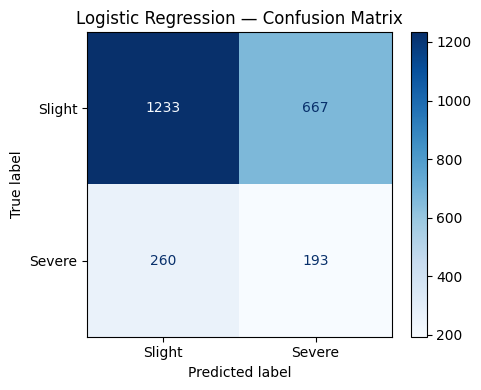

In [56]:
# 5.4a Logistic Regression: confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Slight', 'Severe'],
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

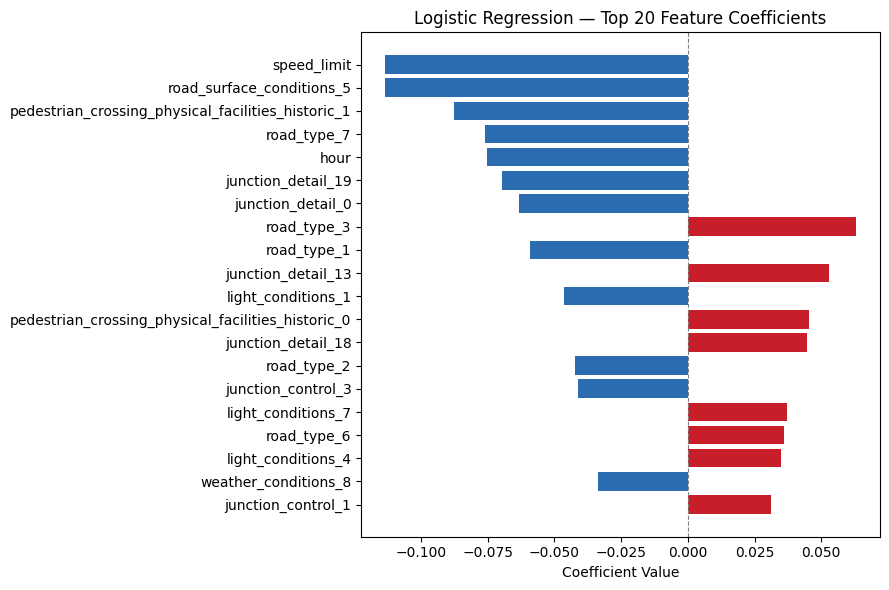

In [57]:
# 5.4b Logistic Regression: top feature coefficients

lr_coef = pd.Series(
    lr_pipeline.named_steps['clf'].coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False).head(20)

colors = ['#C81E2A' if v > 0 else '#2B6CB0' for v in lr_coef.values[::-1]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(lr_coef.index[::-1], lr_coef.values[::-1], color=colors)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression — Top 20 Feature Coefficients')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [58]:
# 5.5a GridSearchCV — Random Forest hyperparameter tuning
# CV only on X_train / y_train; val and test never seen during tuning

from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid_rf = {
    'clf__n_estimators':    [100, 200],
    'clf__max_depth':       [5, 10, None],
    'clf__min_samples_leaf':[2, 5],
    'clf__max_features':    ['sqrt', 'log2'],
    'clf__class_weight':    ['balanced'],
}

rf_tune_pipe = Pipeline([
    ('passthrough', FunctionTransformer()),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    rf_tune_pipe,
    param_grid_rf,
    scoring='average_precision',   # PR-AUC — appropriate for imbalanced data
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

best_rf_params = {
    k.replace('clf__', ''): v
    for k, v in grid_rf.best_params_.items()
}

print("Best RF parameters:")
print(best_rf_params)
print(f"Best CV PR-AUC: {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF parameters:
{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
Best CV PR-AUC: 0.2265


The best parameters were: n_estimators=200, max_depth=10, max_features='sqrt', min_samples_leaf=2, class_weight='balanced' (best CV PR-AUC: 0.2265)

In [59]:
# 5.5 Random Forest with Pipeline

rf_pipeline = Pipeline([
    ('passthrough', FunctionTransformer()),
    ('clf', RandomForestClassifier(
        **best_rf_params,
        random_state=42, n_jobs=-1
    ))
])
rf_pipeline.fit(X_train, y_train)

y_prob_rf_val = rf_pipeline.predict_proba(X_val)[:, 1]
thresh_rf = find_balanced_threshold(y_val, y_prob_rf_val, target_accuracy=0.65)

y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= thresh_rf).astype(int)

print(f"Random Forest — threshold: {thresh_rf:.3f}")
print(classification_report(y_test, y_pred_rf,
      target_names=['Slight', 'Severe']))

rf_metrics = {
    'Model': 'Random Forest',
    'Threshold': round(thresh_rf, 3),
    'Accuracy': round(accuracy_score(y_test, y_pred_rf), 3),
    'Precision': round(precision_score(y_test, y_pred_rf), 3),
    'Recall': round(recall_score(y_test, y_pred_rf), 3),
    'F1': round(f1_score(y_test, y_pred_rf), 3),
    'MCC': round(matthews_corrcoef(y_test, y_pred_rf), 3),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_rf), 3),
    'PR-AUC': round(average_precision_score(y_test, y_prob_rf), 3),
}

Random Forest — threshold: 0.510
              precision    recall  f1-score   support

      Slight       0.82      0.72      0.76      1900
      Severe       0.21      0.32      0.25       453

    accuracy                           0.64      2353
   macro avg       0.51      0.52      0.51      2353
weighted avg       0.70      0.64      0.67      2353



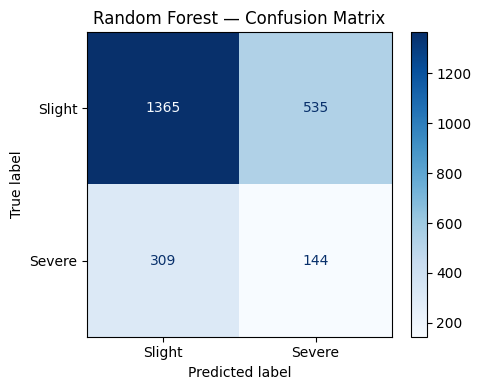

True Positives  (Severe correctly identified): 144
False Negatives (Severe missed by model):      309
False Positives (Slight predicted as Severe):  535
True Negatives  (Slight correctly identified): 1365


In [60]:
# 5.6 Random Forest: confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Slight', 'Severe'],
    cmap='Blues', ax=ax
)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print(f"True Positives  (Severe correctly identified): {tp}")
print(f"False Negatives (Severe missed by model):      {fn}")
print(f"False Positives (Slight predicted as Severe):  {fp}")
print(f"True Negatives  (Slight correctly identified): {tn}")

In [61]:
# 5.7a GridSearchCV — Gradient Boosting hyperparameter tuning

param_grid_gb = {
    'clf__n_estimators':  [100, 200],
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_depth':     [3, 4, 5],
    'clf__subsample':     [0.8, 1.0],
}

gb_tune_pipe = Pipeline([
    ('passthrough', FunctionTransformer()),
    ('clf', GradientBoostingClassifier(random_state=42))
])

grid_gb = GridSearchCV(
    gb_tune_pipe,
    param_grid_gb,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_gb.fit(X_train, y_train)

best_gb_params = {
    k.replace('clf__', ''): v
    for k, v in grid_gb.best_params_.items()
}

print("Best GB parameters:")
print(best_gb_params)
print(f"Best CV PR-AUC: {grid_gb.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best GB parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV PR-AUC: 0.2201


The best parameters from GridSearchCV were: n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8 (best CV PR-AUC: 0.2201).

In [62]:
# 5.7 Gradient Boosting with Pipeline
gb_pipeline = Pipeline([
    ('passthrough', FunctionTransformer()),
    ('clf', GradientBoostingClassifier(
        **best_gb_params,
        random_state=42
    ))
])
gb_pipeline.fit(X_train, y_train)

y_prob_gb_val = gb_pipeline.predict_proba(X_val)[:, 1]
thresh_gb = find_balanced_threshold(y_val, y_prob_gb_val, target_accuracy=0.65)

y_prob_gb = gb_pipeline.predict_proba(X_test)[:, 1]
y_pred_gb = (y_prob_gb >= thresh_gb).astype(int)

print(f"Gradient Boosting — threshold: {thresh_gb:.3f}")
print(classification_report(y_test, y_pred_gb,
      target_names=['Slight', 'Severe']))

gb_metrics = {
    'Model': 'Gradient Boosting',
    'Threshold': round(thresh_gb, 3),
    'Accuracy': round(accuracy_score(y_test, y_pred_gb), 3),
    'Precision': round(precision_score(y_test, y_pred_gb), 3),
    'Recall': round(recall_score(y_test, y_pred_gb), 3),
    'F1': round(f1_score(y_test, y_pred_gb), 3),
    'MCC': round(matthews_corrcoef(y_test, y_pred_gb), 3),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_gb), 3),
    'PR-AUC': round(average_precision_score(y_test, y_prob_gb), 3),
}

Gradient Boosting — threshold: 0.220
              precision    recall  f1-score   support

      Slight       0.82      0.70      0.76      1900
      Severe       0.22      0.34      0.26       453

    accuracy                           0.63      2353
   macro avg       0.52      0.52      0.51      2353
weighted avg       0.70      0.63      0.66      2353



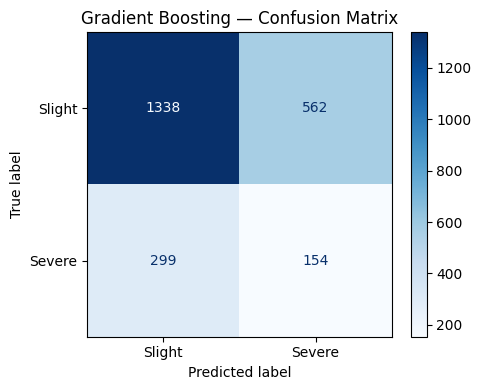

True Positives  (Severe correctly identified): 154
False Negatives (Severe missed by model):      299
False Positives (Slight predicted as Severe):  562
True Negatives  (Slight correctly identified): 1338


In [63]:
# 5.8 Gradient Boosting: confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gb,
    display_labels=['Slight', 'Severe'],
    cmap='Blues', ax=ax
)
ax.set_title('Gradient Boosting — Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_gb).ravel()
print(f"True Positives  (Severe correctly identified): {tp}")
print(f"False Negatives (Severe missed by model):      {fn}")
print(f"False Positives (Slight predicted as Severe):  {fp}")
print(f"True Negatives  (Slight correctly identified): {tn}")

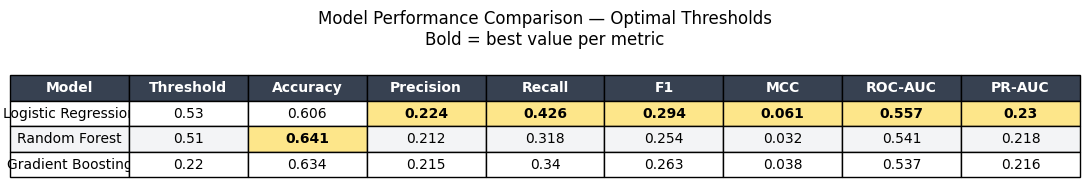

=== Model Comparison ===
              Model  Threshold  Accuracy  Precision  Recall    F1   MCC  ROC-AUC  PR-AUC
Logistic Regression       0.53     0.606      0.224   0.426 0.294 0.061    0.557   0.230
      Random Forest       0.51     0.641      0.212   0.318 0.254 0.032    0.541   0.218
  Gradient Boosting       0.22     0.634      0.215   0.340 0.263 0.038    0.537   0.216


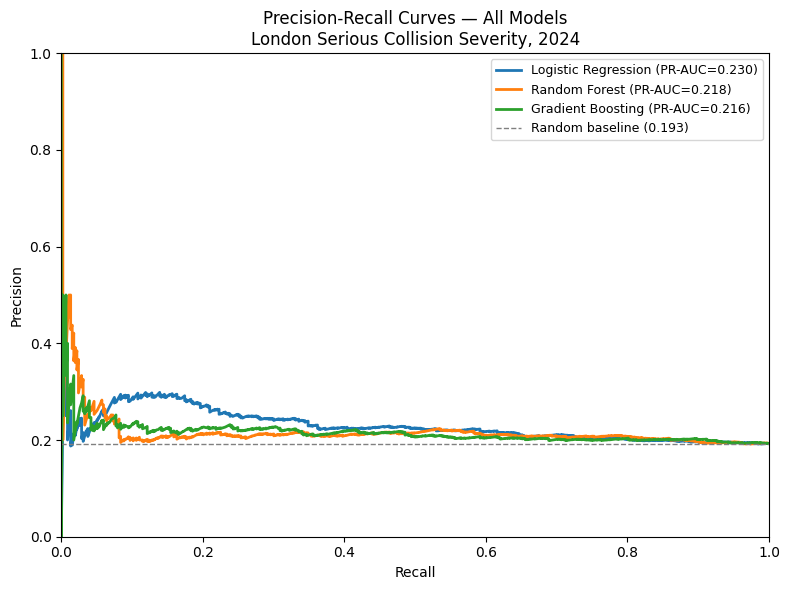

In [64]:
# 5.9 Full model comparison table and PR curves

comparison = pd.DataFrame([lr_metrics, rf_metrics, gb_metrics])
cols = ['Model', 'Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'MCC', 'ROC-AUC', 'PR-AUC']

fig, ax = plt.subplots(figsize=(11, 2))
ax.axis('off')

table = ax.table(
    cellText=comparison[cols].values.tolist(),
    colLabels=cols,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Header: dark grey
for j in range(len(cols)):
    table[0, j].set_facecolor('#374151')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Rows: alternating white and light grey
row_bg = ['#ffffff', '#f3f4f6', '#ffffff']
for i in range(1, 4):
    for j in range(len(cols)):
        table[i, j].set_facecolor(row_bg[i-1])

# Highlight best value per metric in soft amber
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'MCC', 'ROC-AUC', 'PR-AUC']
for col_name in metric_cols:
    col_idx = cols.index(col_name)
    values = comparison[col_name].values
    best_row = values.argmax() + 1
    table[best_row, col_idx].set_facecolor('#fde68a')
    table[best_row, col_idx].set_text_props(fontweight='bold')

ax.set_title(
    'Model Performance Comparison — Optimal Thresholds\n'
    'Bold = best value per metric',
    fontsize=12, pad=20
)
plt.tight_layout()
plt.show()

print("=== Model Comparison ===")
print(comparison[cols].to_string(index=False))

# PR curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, '#2B6CB0'),
    ('Random Forest',       y_prob_rf, '#D97706'),
    ('Gradient Boosting',   y_prob_gb, '#276749'),
]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, label=f'{name} (PR-AUC={ap:.3f})', linewidth=2)

ax.axhline(y_test.mean(), color='grey', linestyle='--', linewidth=1,
           label=f'Random baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models\nLondon Serious Collision Severity, 2024')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**Model comparison**

All three models achieved PR-AUC above the random baseline of 0.193, confirming that road-context variables carry predictive signal for collision severity. Logistic Regression achieved the highest PR-AUC (0.230) and the highest recall (0.426), with a selected threshold of 0.530. This suggests that much of the predictive signal in this dataset is captured by linear relationships. Random Forest achieved the highest accuracy (0.641) with a threshold of 0.510, but the lowest recall (0.318) among the three models. Gradient Boosting, with a lower threshold of 0.220, produced a recall of 0.340 and PR-AUC of 0.216. MCC values are low across all models (0.032–0.061), confirming that performance gains above the no-information baseline are modest. The overall modest performance is consistent with the observability constraints of STATS19 data, which does not record impact speed, driver behaviour, or pedestrian vulnerability at the individual collision level.

In [65]:
# 5.10 SHAP
import shap
X_shap = X_test.copy()
gb_clf = gb_pipeline.named_steps['clf']
explainer = shap.TreeExplainer(gb_clf)
shap_values = explainer.shap_values(X_shap)

In [66]:
# 5.10b Read STATS19 data guide from GitHub to verify crossing facility codes,
# then build feature name decoder for SHAP plots

import io
import requests

DATA_GUIDE_URL = (
    'https://raw.githubusercontent.com/Alexia418/'
    'DSSS_Assessment/main/'
    'dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2024.xlsx'
)

response = requests.get(DATA_GUIDE_URL)
guide_raw = pd.read_excel(
    io.BytesIO(response.content),
    sheet_name='2024_code_list'
)

# Extract and display crossing facility codes for verification
crossing_codes = guide_raw[
    guide_raw['field name'] == 'pedestrian_crossing_physical_facilities_historic'
][['field name', 'code/format', 'label']].dropna(subset=['label'])

print("Crossing facility codes (from DfT data guide 2024):")
print(crossing_codes.to_string(index=False))

# Build feature name decoder using verified STATS19 coding
feature_name_map = {
    'speed_limit':  'Speed limit (mph)',
    'hour':         'Hour of day',

    'pedestrian_crossing_physical_facilities_historic_0': 'Crossing: No facility (within 50m)',
    'pedestrian_crossing_physical_facilities_historic_1': 'Crossing: Zebra',
    'pedestrian_crossing_physical_facilities_historic_4': 'Crossing: Pelican/Puffin/Toucan',
    'pedestrian_crossing_physical_facilities_historic_5': 'Crossing: Pedestrian phase at signal',
    'pedestrian_crossing_physical_facilities_historic_7': 'Crossing: Footbridge or subway',
    'pedestrian_crossing_physical_facilities_historic_8': 'Crossing: Central refuge',

    'junction_detail_0':  'Junction: Not at junction',
    'junction_detail_13': 'Junction: T or staggered',
    'junction_detail_16': 'Junction: Crossroads',
    'junction_detail_17': 'Junction: More than 4 arms',
    'junction_detail_18': 'Junction: Private drive',
    'junction_detail_19': 'Junction: Mini-roundabout',

    'junction_control_0': 'Control: Not at junction',
    'junction_control_1': 'Control: Authorised person',
    'junction_control_2': 'Control: Auto traffic signal',
    'junction_control_3': 'Control: Stop sign',
    'junction_control_4': 'Control: Give way/uncontrolled',

    'road_type_1':  'Road: Roundabout',
    'road_type_2':  'Road: One-way street',
    'road_type_3':  'Road: Dual carriageway',
    'road_type_6':  'Road: Single carriageway',
    'road_type_7':  'Road: Slip road',
    'road_type_12': 'Road: One-way/Slip road',

    'light_conditions_1': 'Light: Daylight',
    'light_conditions_4': 'Light: Darkness (street lit)',
    'light_conditions_5': 'Light: Darkness (unlit)',
    'light_conditions_6': 'Light: Darkness (no lighting)',
    'light_conditions_7': 'Light: Darkness (lighting unknown)',

    'weather_conditions_1': 'Weather: Fine',
    'weather_conditions_2': 'Weather: Raining',
    'weather_conditions_3': 'Weather: Snowing',
    'weather_conditions_4': 'Weather: Fine + wind',
    'weather_conditions_5': 'Weather: Raining + wind',
    'weather_conditions_6': 'Weather: Snowing + wind',
    'weather_conditions_7': 'Weather: Fog or mist',
    'weather_conditions_8': 'Weather: Other',

    'road_surface_conditions_1': 'Surface: Dry',
    'road_surface_conditions_2': 'Surface: Wet or damp',
    'road_surface_conditions_3': 'Surface: Snow',
    'road_surface_conditions_4': 'Surface: Frost or ice',
    'road_surface_conditions_5': 'Surface: Flood',

    'urban_or_rural_area_1': 'Area: Urban',
    'urban_or_rural_area_2': 'Area: Rural',

    'day_of_week_1': 'Day: Sunday',
    'day_of_week_2': 'Day: Monday',
    'day_of_week_3': 'Day: Tuesday',
    'day_of_week_4': 'Day: Wednesday',
    'day_of_week_5': 'Day: Thursday',
    'day_of_week_6': 'Day: Friday',
    'day_of_week_7': 'Day: Saturday',

    'peak_hour_0': 'Off-peak hour',
    'peak_hour_1': 'Peak hour (07-09 / 16-19)',
    'weekend_0':   'Weekday',
    'weekend_1':   'Weekend',
}

X_shap_named = X_shap.rename(columns=feature_name_map)

decoded = sum(1 for c in X_shap.columns if c in feature_name_map)
print(f"\nDecoder built: {len(feature_name_map)} entries")
print(f"Columns decoded: {decoded} of {len(X_shap.columns)}")

Crossing facility codes (from DfT data guide 2024):
                                      field name code/format                                                                     label
pedestrian_crossing_physical_facilities_historic           0                          No physical crossing facilities within 50 metres
pedestrian_crossing_physical_facilities_historic           1                                                                     Zebra
pedestrian_crossing_physical_facilities_historic           4 Pelican, puffin, toucan or similar non-junction pedestrian light crossing
pedestrian_crossing_physical_facilities_historic           5                               Pedestrian phase at traffic signal junction
pedestrian_crossing_physical_facilities_historic           7                                                      Footbridge or subway
pedestrian_crossing_physical_facilities_historic           8                                                            Central refuge
ped

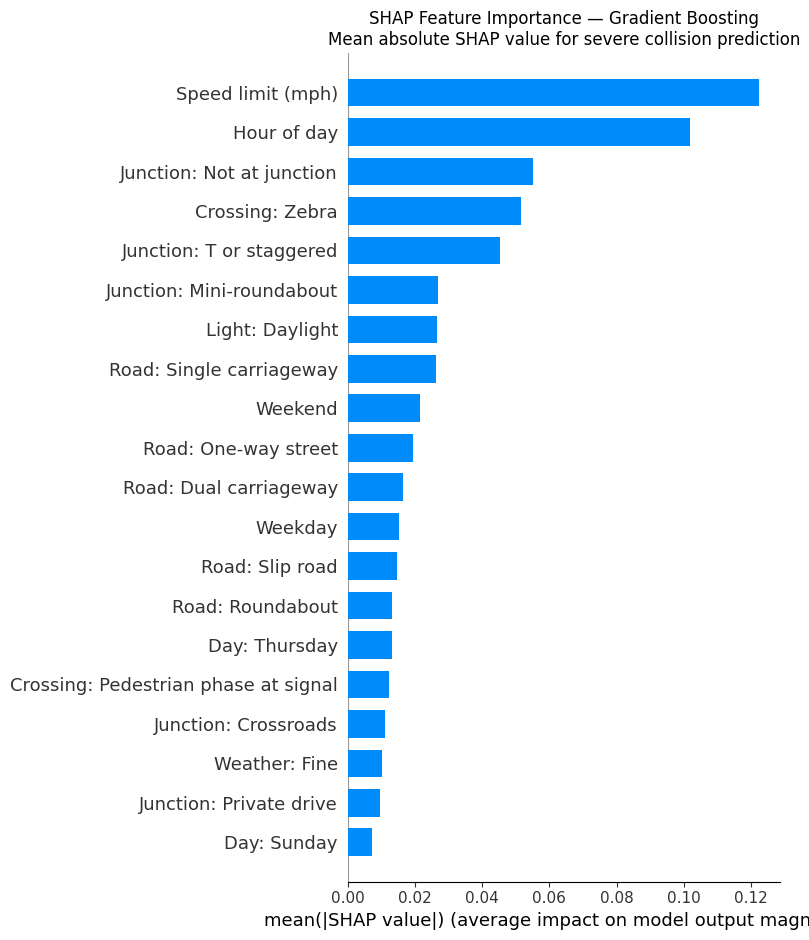

In [67]:
# 5.11 SHAP bar chart with readable feature names

shap.summary_plot(
    shap_values, X_shap_named,
    plot_type='bar', max_display=20, show=False
)
plt.title(
    'SHAP Feature Importance — Gradient Boosting\n'
    'Mean absolute SHAP value for severe collision prediction',
    fontsize=12
)
plt.tight_layout()
plt.show()

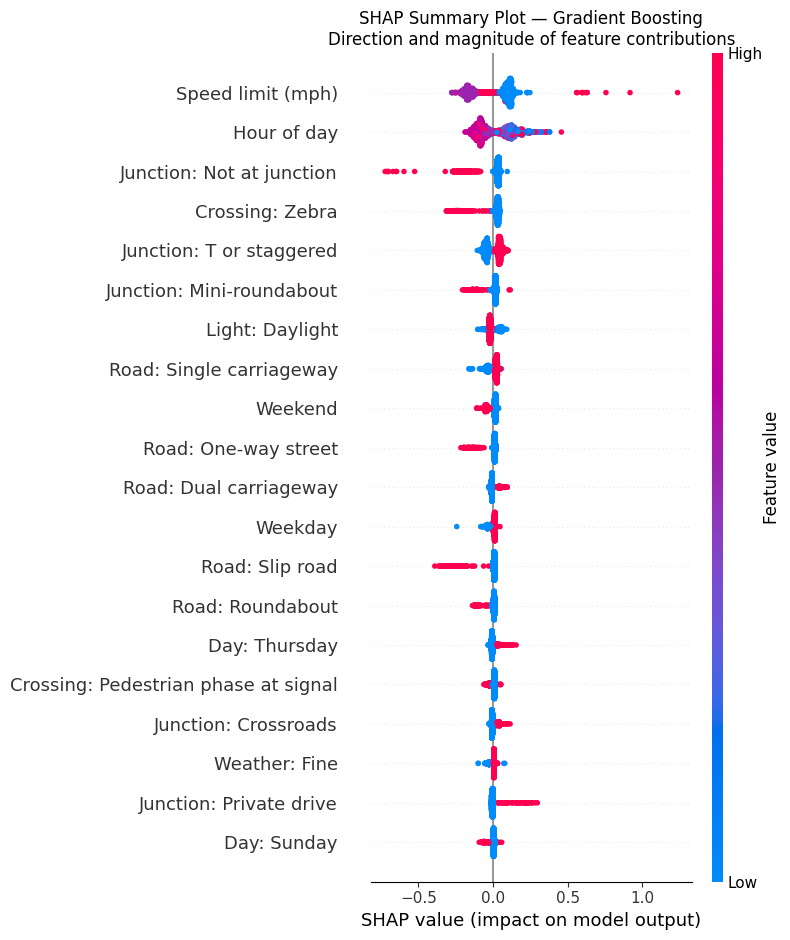

In [68]:
# 5.12 SHAP beeswarm with readable feature names

shap.summary_plot(
    shap_values, X_shap_named,
    plot_type='dot', max_display=20, show=False
)
plt.title(
    'SHAP Summary Plot — Gradient Boosting\n'
    'Direction and magnitude of feature contributions',
    fontsize=12
)
plt.tight_layout()
plt.show()

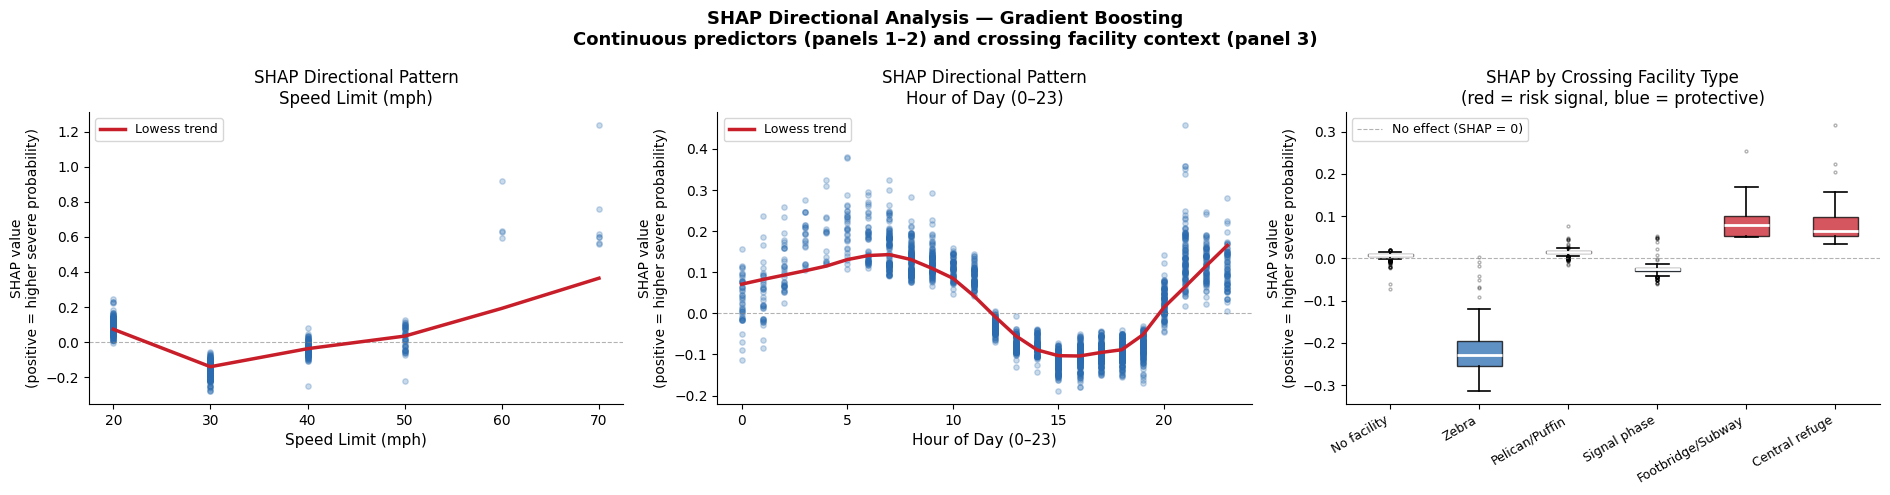

In [69]:
# 5.12b SHAP directional scatter — speed_limit, hour, and crossing facility type
# Three panels: continuous predictors (scatter+lowess) + categorical (boxplot)
# Together these directly answer RQ2: direction and magnitude of key predictors

import statsmodels.api as sm

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# --- Panel 1 & 2: continuous features (scatter + lowess) ---
focus_features = {
    'speed_limit': 'Speed Limit (mph)',
    'hour':        'Hour of Day (0–23)',
}

for ax, (feat, label) in zip(axes[:2], focus_features.items()):
    if feat not in X_shap.columns:
        continue

    feat_idx   = list(X_shap.columns).index(feat)
    feat_vals  = X_shap[feat].values
    shap_vals  = shap_values[:, feat_idx]

    sort_idx    = np.argsort(feat_vals)
    x_sorted    = feat_vals[sort_idx]
    shap_sorted = shap_vals[sort_idx]

    lowess_result = sm.nonparametric.lowess(
        shap_sorted, x_sorted, frac=0.3, return_sorted=True
    )

    ax.scatter(feat_vals, shap_vals,
               alpha=0.25, s=15, color='#2B6CB0', zorder=2)
    ax.plot(lowess_result[:, 0], lowess_result[:, 1],
            color='#C81E2A', linewidth=2.5, zorder=3, label='Lowess trend')
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)

    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('SHAP value\n(positive = higher severe probability)', fontsize=10)
    ax.set_title(f'SHAP Directional Pattern\n{label}', fontsize=12)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# --- Panel 3: crossing facility type boxplot ---
ax3 = axes[2]

# Crossing facility labels (matching one-hot column names after encoding)
crossing_display = {
    'pedestrian_crossing_physical_facilities_historic_0': 'No facility',
    'pedestrian_crossing_physical_facilities_historic_1': 'Zebra',
    'pedestrian_crossing_physical_facilities_historic_4': 'Pelican/Puffin',
    'pedestrian_crossing_physical_facilities_historic_5': 'Signal phase',
    'pedestrian_crossing_physical_facilities_historic_7': 'Footbridge/Subway',
    'pedestrian_crossing_physical_facilities_historic_8': 'Central refuge',
}

box_data   = []
box_labels = []
box_colors = []

for col, display_name in crossing_display.items():
    if col not in X_shap.columns:
        continue
    col_idx   = list(X_shap.columns).index(col)
    shap_vals = shap_values[:, col_idx]
    # Only include rows where this facility type was present (one-hot = 1)
    mask      = X_shap[col].values == 1
    if mask.sum() < 5:
        continue
    box_data.append(shap_vals[mask])
    box_labels.append(display_name)
    # Red if median SHAP > 0 (risk signal), blue if < 0 (protective)
    box_colors.append('#C81E2A' if np.median(shap_vals[mask]) > 0 else '#2B6CB0')

bp = ax3.boxplot(
    box_data,
    vert=True,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
)

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax3.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.6,
            label='No effect (SHAP = 0)')
ax3.set_xticks(range(1, len(box_labels) + 1))
ax3.set_xticklabels(box_labels, rotation=30, ha='right', fontsize=9)
ax3.set_ylabel('SHAP value\n(positive = higher severe probability)', fontsize=10)
ax3.set_title('SHAP by Crossing Facility Type\n(red = risk signal, blue = protective)', fontsize=12)
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.suptitle(
    'SHAP Directional Analysis — Gradient Boosting\n'
    'Continuous predictors (panels 1–2) and crossing facility context (panel 3)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

Three SHAP outputs were produced: a bar chart of mean absolute SHAP values, a beeswarm plot showing direction and distribution, and directional scatter plots with lowess trend lines for speed_limit and hour, accompanied by a boxplot of SHAP values disaggregated by crossing facility type.

**Feature importance and direction**

The bar chart and beeswarm identified speed_limit and hour as the dominant predictors by mean absolute SHAP value. The directional scatter plot for speed_limit shows a positive trend with increasing feature values: higher posted speed limits are associated with higher SHAP values, indicating an increased predicted probability of a severe outcome, consistent with the physical relationship between vehicle speed and injury severity. The hour scatter plot reveals a non-linear pattern across the day.


In [70]:
# 5.13 SHAP values for crossing facility features specifically

crossing_cols = [
    c for c in X_shap_named.columns
    if c.startswith('Crossing:')
]

crossing_shap = pd.Series({
    col: np.abs(
        shap_values[:, list(X_shap_named.columns).index(col)]
    ).mean()
    for col in crossing_cols
}).sort_values(ascending=False)

print("Mean absolute SHAP — crossing facility categories:")
print(crossing_shap.to_string())

Mean absolute SHAP — crossing facility categories:
Crossing: Zebra                         0.051520
Crossing: Pedestrian phase at signal    0.012277
Crossing: No facility (within 50m)      0.006695
Crossing: Central refuge                0.004931
Crossing: Pelican/Puffin/Toucan         0.003355
Crossing: Footbridge or subway          0.000893


**Crossing facility SHAP values**

Among crossing facility categories, Zebra crossing recorded the highest mean absolute SHAP value (0.0515), followed by Pedestrian phase at signal junction (0.0123), No facility within 50m (0.0067), Central refuge (0.0049), Pelican/Puffin/Toucan (0.0034), and Footbridge or subway (0.0009). All crossing facility SHAP values are substantially lower than those for speed_limit and hour. The SHAP boxplot shows the directional contribution of each facility type: where the median SHAP for a facility type is negative, the model associates its presence with a lower predicted probability of a severe outcome relative to the baseline. These results indicate that crossing facility type is not a strong independent predictor of severity in this model, and that speed limit and time of day dominate the prediction.


**Limitations and interpretation**

There are several limitations in this study. The analysis is conditional on a collision having been recorded in STATS19: slight collisions are more likely to be under-reported than fatal or serious ones, which may affect the class distribution and model training. Pedestrian exposure data (the volume of pedestrians at each location) is absent from STATS19. Crossing facilities are typically installed at high-exposure locations, meaning the conditional severe rate at a facility location may be lower not because of the facility itself, but because those locations attract more pedestrian traffic overall. This confounds direct interpretation of facility effects on severity. All model outputs represent predictive associations, not causal effects, and the distribution of crossing facilities reflects historical planning decisions and past collision patterns. Finally, spatial autocorrelation between nearby collisions is not modelled, which may affect the independence assumption of the train-test split.


## Conclusion

[[ go back to the top ]](#Table-of-contents)

This study examined whether pedestrian crossing facilities in London are associated with lower serious collision severity, or act as signals of high-risk junction contexts in machine learning predictions, using STATS19 2024 collision records.

Addressing RQ1, EDA showed that severe collision rates vary across crossing facility types and junction contexts. The heatmap of crossing facility by junction type produced a range of 0.00 to 0.50, confirming that junction context is a critical moderating factor and that facility type cannot be interpreted in isolation.

Addressing RQ2, all three models achieved PR-AUC above the random baseline of 0.193. Logistic Regression performed best on PR-AUC (0.230) and recall (0.426), indicating that the predictive signal in this dataset is primarily linear. SHAP analysis identified speed limit and hour of day as the dominant predictors. Crossing facility categories contributed substantially lower SHAP values, with Zebra crossing highest at 0.0515. These findings indicate that crossing facilities do not act as strong risk signals in the model, and that their presence is not a dominant driver of severity prediction relative to road speed and temporal context.

These results suggest that road safety targeting should focus on the interplay between speed environment and junction type, rather than crossing facility presence alone. Future research should incorporate pedestrian flow data and finer spatial scales to separate infrastructure effects from exposure effects.

## References

[[ go back to the top ]](#Table-of-contents)

Chang, I., Park, H., Hong, E., Lee, J. and Kwon, N. (2022). Predicting effects of built environment on fatal pedestrian accidents at location-specific level: Application of XGBoost and SHAP. Accident Analysis & Prevention, 166, p.106545. doi:https://doi.org/10.1016/j.aap.2021.106545.
‌

Chen, Y., Zhu, J., Long, J., Lin, H., Liu, H. and Xiang, B. (2026). Application of the dual-model interpretability framework of XGBoost-SHAP and GAT-GNNExplainer to investigate the impact of the built environment on traffic accidents at intersections. Accident Analysis & Prevention, 224, p.108305. doi:https://doi.org/10.1016/j.aap.2025.108305.

‌
Department for Transport (2024) Road Safety Data: Reported Road Casualties Great Britain 2024. Available at: https://www.data.gov.uk/dataset/cb7ae6f0-4be6-4935-9277-47e5ce24a11f/road-safety-data


D. Alex Quistberg, Howard, E.W., Ebel, B.E., Anne Vernez Moudon, Saelens, B.E., Hurvitz, P.M., Curtin, J.F. and Rivara, F.P. (2015). Multilevel models for evaluating the risk of pedestrian-motor vehicle collisions at intersections and mid-blocks. Accident Analysis & Prevention, 84, pp.99–111. doi:https://doi.org/10.1016/j.aap.2015.08.013.
‌

Kuşkapan, E., Sahraei, M.A., Çodur, M.K. and Çodur, M.Y. (2022). Pedestrian safety at signalized intersections: Spatial and machine learning approaches. Journal of Transport & Health, 24, p.101322. doi:https://doi.org/10.1016/j.jth.2021.101322.
‌

Office for National Statistics (2023) London Borough Boundaries. Available at: https://geoportal.statistics.gov.uk


Olszewski, P., Szagała, P., Wolański, M. and Zielińska, A. (2015). Pedestrian fatality risk in accidents at unsignalized zebra crosswalks in Poland. Accident Analysis & Prevention, 84, pp.83–91. doi:https://doi.org/10.1016/j.aap.2015.08.008.


Www.london.gov.uk. (n.d.). Vision Zero for London | London City Hall. [online] Available at: https://www.london.gov.uk/programmes-strategies/transport/improving-londons-roads/vision-zero-london.
‌